In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download(
    "ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data"
)
print("Dataset path:", path)

base_path = path + "/HDFS_v1/preprocessed"
traces_path = base_path + "/Event_traces.csv"

trace_df = pd.read_csv(traces_path)
print("trace_df shape:", trace_df.shape)
print(trace_df.head())

100%|█████████████████████████████████████████████████████████████████████████████| 1.55G/1.55G [01:10<00:00, 23.6MB/s]

Extracting files...


Dataset path: C:\Users\serge\.cache\kagglehub\datasets\ayenuryrr\loghub-hdfs-hadoop-distributed-file-system-data\versions\3
trace_df shape: (575061, 6)
                    BlockId    Label  Type  \
0  blk_-1608999687919862906  Success   NaN   
1   blk_7503483334202473044  Success   NaN   
2  blk_-3544583377289625738     Fail  21.0   
3  blk_-9073992586687739851  Success   NaN   
4   blk_7854771516489510256  Success   NaN   

                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                        TimeInterval  Latency  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
1  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0

In [ ]:
trace_df.head()

,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583


In [ ]:
def parse_sequence(s):
    if pd.isna(s):
        return []

    s = str(s).strip()

    if s == "":
        return []


    s = s.strip("[]")

    if s == "":
        return []

    items = [item.strip().strip("'").strip('"') for item in s.split(",")]
    items = [item for item in items if item != ""]

    return items

def parse_float_sequence(s):
    if pd.isna(s):
        return []

    s = str(s).strip()

    if s == "":
        return []

    s = s.strip("[]")

    if s == "":
        return []

    result = []
    for item in s.split(","):
        item = item.strip()
        if item == "":
            continue
        try:
            result.append(float(item))
        except ValueError:
            continue

    return result

перевод строк → структурированные данные, из строки в список

In [ ]:
df = trace_df.copy()

df["sequence"] = df["Features"].apply(parse_sequence)
df["time_seq"] = df["TimeInterval"].apply(parse_float_sequence)

df["label"] = df["Label"].map({
    "Success": 0,
    "Fail": 1
})

df["seq_len"] = df["sequence"].apply(len)
df["time_len"] = df["time_seq"].apply(len)

print("\nInitial stats")
print("Original size:", len(df))
print("Missing labels:", df["label"].isna().sum())
print("Empty sequences:", (df["seq_len"] == 0).sum())
print(df["label"].value_counts(dropna=False))
print(df["seq_len"].describe())

df = df[df["label"].notna()].copy()
df = df[df["seq_len"] > 0].copy()


df = df[df["label"].notna()].copy()
df = df[df["seq_len"] > 0].copy()


MIN_SEQ_LEN = 5
df = df[df["seq_len"] >= MIN_SEQ_LEN].copy()


print("\nAfter basic cleaning:", len(df))
print(df["label"].value_counts())


Initial stats
Original size: 575061
Missing labels: 0
Empty sequences: 0
label
0    558223
1     16838
Name: count, dtype: int64
count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: seq_len, dtype: float64

After basic cleaning: 568880
label
0    558223
1     10657
Name: count, dtype: int64


Закодировала целевую переменную

In [ ]:
print("Anomaly ratio:", df["label"].mean())
print("Unique feature patterns:", df["Features"].nunique())

print("\nSequence length percentiles:")
print(df["seq_len"].quantile([0.5, 0.9, 0.95, 0.99]))

print("\nExample sequences:")
print(df[["sequence", "label"]].head(3))

Anomaly ratio: 0.01873330052032063
Unique feature patterns: 18366

Sequence length percentiles:
0.50    19.0
0.90    25.0
0.95    28.0
0.99    33.0
Name: seq_len, dtype: float64

Example sequences:
                                            sequence  label
0  [E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...      0
1  [E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...      0
2  [E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...      1


In [ ]:
mismatch_count = (df["seq_len"] != df["time_len"]).sum()
print("\nSequence/time length mismatch count:", mismatch_count)

if mismatch_count > 0:
    print(df.loc[df["seq_len"] != df["time_len"],
                 ["Features", "TimeInterval", "seq_len", "time_len"]].head())


Sequence/time length mismatch count: 568880
                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                        TimeInterval  seq_len  time_len  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...      269       268  
1  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...       22        21  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...      223       222  
3  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...       22        21  
4  [0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...       38        37  


для всех наблюдений длина последовательности временных интервалов меньше длины последовательности событий на единицу

In [ ]:
interval_match_count = (df["seq_len"] == df["time_len"] + 1).sum()
print("seq_len == time_len + 1:", interval_match_count)
print("ratio:", interval_match_count / len(df))

seq_len == time_len + 1: 568880
ratio: 1.0


In [ ]:
feature_label_counts = df.groupby("Features")["label"].nunique()
conflicting_features = feature_label_counts[feature_label_counts > 1].index

print("\nConflicting sequences:", len(conflicting_features))

df_clean = df[~df["Features"].isin(conflicting_features)].copy()

print("After removing conflicts:", len(df_clean))
print(df_clean["label"].value_counts())
print("Unique feature patterns:", df_clean["Features"].nunique())


Conflicting sequences: 10
After removing conflicts: 568834
label
0    558201
1     10633
Name: count, dtype: int64
Unique feature patterns: 18356


были выявлены случаи, при которых одна и та же последовательность событий соответствует различным меткам (как успешному, так и неуспешному выполнению). такие наблюдения являются противоречивыми и могут негативно влиять на процесс обучения модели

In [ ]:
print("Before:", df["Features"].nunique())
print("Conflicting unique features:", len(conflicting_features))
print("Expected after:", df["Features"].nunique() - len(conflicting_features))
print("Actual after:", df_clean["Features"].nunique())

Before: 18366
Conflicting unique features: 10
Expected after: 18356
Actual after: 18356


In [ ]:
feature_labels = (
    df_clean.groupby("Features")["label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("\nfeature_labels shape:", feature_labels.shape)
print(feature_labels["label"].value_counts())

train_feat, temp_feat = train_test_split(
    feature_labels,
    test_size=0.30,
    stratify=feature_labels["label"],
    random_state=42
)

val_feat, test_feat = train_test_split(
    temp_feat,
    test_size=0.50,
    stratify=temp_feat["label"],
    random_state=42
)

train_features = set(train_feat["Features"])
val_features = set(val_feat["Features"])
test_features = set(test_feat["Features"])

train_df = df_clean[df_clean["Features"].isin(train_features)].copy()
val_df = df_clean[df_clean["Features"].isin(val_features)].copy()
test_df = df_clean[df_clean["Features"].isin(test_features)].copy()


def summarize_split(name, split_df):
    print(f"\n{name}")
    print("  instances:", len(split_df))
    print("  unique patterns:", split_df["Features"].nunique())
    print("  label counts:")
    print(split_df["label"].value_counts())
    print("  anomaly ratio:", round(split_df["label"].mean(), 4))


summarize_split("Train", train_df)
summarize_split("Validation", val_df)
summarize_split("Test", test_df)

train_set = set(train_df["Features"].astype(str))
val_set = set(val_df["Features"].astype(str))
test_set = set(test_df["Features"].astype(str))

print("\nOverlap check")
print("Train ∩ Val :", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test  :", len(val_set & test_set))

train_seq_set = set(train_df["sequence"].apply(tuple))
val_seq_set = set(val_df["sequence"].apply(tuple))
test_seq_set = set(test_df["sequence"].apply(tuple))

print("\nSequence overlap check")
print("Train ∩ Val :", len(train_seq_set & val_seq_set))
print("Train ∩ Test:", len(train_seq_set & test_seq_set))
print("Val ∩ Test  :", len(val_seq_set & test_seq_set))


feature_labels shape: (18356, 2)
label
0    14249
1     4107
Name: count, dtype: int64

Train
  instances: 359655
  unique patterns: 12849
  label counts:
label
0    352608
1      7047
Name: count, dtype: int64
  anomaly ratio: 0.0196

Validation
  instances: 71974
  unique patterns: 2753
  label counts:
label
0    70237
1     1737
Name: count, dtype: int64
  anomaly ratio: 0.0241

Test
  instances: 137205
  unique patterns: 2754
  label counts:
label
0    135356
1      1849
Name: count, dtype: int64
  anomaly ratio: 0.0135

Overlap check
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Sequence overlap check
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


 для каждой уникальной последовательности Features определяется одна метка label. Затем разбивается на train/val/test. Из уникальных последовательностей собираются паттерны, после этого в train_df, val_df, test_df попадают все строки, чьи Features принадлежат соответствующей группе паттернов.

In [ ]:
normal_train_df = train_df[train_df["label"] == 0].copy()

print("\nNormal train size:", len(normal_train_df))
print("Normal train unique patterns:", normal_train_df["Features"].nunique())


Normal train size: 352608
Normal train unique patterns: 9974


из train_df взяты только нормальные последовательности, у которых: label = 0

In [ ]:
from collections import Counter

def build_vocab(sequences, min_freq=1):
    counter = Counter()
    for seq in sequences:
        counter.update(seq)

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for token, count in counter.items():
        if count >= min_freq:
            vocab[token] = len(vocab)

    return vocab, counter

vocab, token_counter = build_vocab(normal_train_df["sequence"], min_freq=1)

print("\nVocab size:", len(vocab))
print("Top 10 tokens:", token_counter.most_common(10))


Vocab size: 18
Top 10 tokens: [('E26', 1060890), ('E5', 1059497), ('E11', 1057824), ('E9', 1057824), ('E21', 899191), ('E23', 897718), ('E22', 352608), ('E3', 308292), ('E4', 247096), ('E2', 83494)]


каждому событию даётся уникальный номер, всего получилось 18 токенов

In [ ]:
print("<PAD>" in token_counter)
print("<UNK>" in token_counter)

False
False


In [ ]:
print("Unique tokens:", len(token_counter))
print("Expected vocab:", len(token_counter) + 2)
print("Actual vocab:", len(vocab))

Unique tokens: 16
Expected vocab: 18
Actual vocab: 18


In [ ]:
def encode_sequence(seq, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in seq]

for split_name, split_df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
    ("normal_train", normal_train_df),
]:
    split_df["sequence_ids"] = split_df["sequence"].apply(lambda x: encode_sequence(x, vocab))
    split_df["seq_len_ids"] = split_df["sequence_ids"].apply(len)
    print(f"\n{split_name} encoded")
    print(split_df["seq_len_ids"].describe())



MAX_LEN = int(np.percentile(normal_train_df["seq_len_ids"], 95))
MAX_LEN = max(MAX_LEN, 5)

print("\nChosen MAX_LEN:", MAX_LEN)


train encoded
count    359655.000000
mean         20.048299
std           4.889883
min           8.000000
25%          19.000000
50%          19.000000
75%          22.000000
max         280.000000
Name: seq_len_ids, dtype: float64

val encoded
count    71974.000000
mean        17.545767
std          5.995525
min         13.000000
25%         13.000000
50%         14.000000
75%         20.000000
max        278.000000
Name: seq_len_ids, dtype: float64

test encoded
count    137205.000000
mean         19.547648
std           3.969623
min           8.000000
25%          19.000000
50%          19.000000
75%          19.000000
max         298.000000
Name: seq_len_ids, dtype: float64

normal_train encoded
count    352608.000000
mean         19.940347
std           4.765715
min          13.000000
25%          19.000000
50%          19.000000
75%          22.000000
max         280.000000
Name: seq_len_ids, dtype: float64

Chosen MAX_LEN: 28


In [ ]:
print("Train length quantiles:")
print(train_df["seq_len_ids"].quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))

print("\nVal length quantiles:")
print(val_df["seq_len_ids"].quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))

print("\nTest length quantiles:")
print(test_df["seq_len_ids"].quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))

Train length quantiles:
0.01    13.0
0.05    13.0
0.10    13.0
0.50    19.0
0.90    25.0
0.95    28.0
0.99    35.0
Name: seq_len_ids, dtype: float64

Val length quantiles:
0.01    13.0
0.05    13.0
0.10    13.0
0.50    14.0
0.90    25.0
0.95    28.0
0.99    35.0
Name: seq_len_ids, dtype: float64

Test length quantiles:
0.01    13.0
0.05    13.0
0.10    19.0
0.50    19.0
0.90    24.0
0.95    25.0
0.99    31.0
Name: seq_len_ids, dtype: float64


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, average_precision_score

def find_best_threshold(scores, labels, num_steps=200):
    scores = np.array(scores)
    labels = np.array(labels)

    thresholds = np.linspace(scores.min(), scores.max(), num_steps)

    best = {
        "threshold": None,
        "f1": -1,
        "precision": 0,
        "recall": 0
    }

    for thr in thresholds:
        preds = (scores >= thr).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="binary", zero_division=0
        )

        if f1 > best["f1"]:
            best = {
                "threshold": thr,
                "f1": f1,
                "precision": precision,
                "recall": recall
            }

    return best


def evaluate_anomaly_scores(test_labels, test_scores, threshold):
    preds = (np.array(test_scores) >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        test_labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(test_labels, preds)

    roc_auc = roc_auc_score(test_labels, test_scores)
    pr_auc = average_precision_score(test_labels, test_scores)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

# Top-1 Frequency baseline

In [ ]:
from collections import Counter

next_event_counter = Counter()

for seq in normal_train_df["sequence"]:
    for i in range(1, len(seq)):
        next_event_counter.update([seq[i]])

global_top1_event, global_top1_count = next_event_counter.most_common(1)[0]

print("Global Top-1 next event:", global_top1_event)
print("Count:", global_top1_count)

Global Top-1 next event: E26
Count: 1060858


In [ ]:
def top1_frequency_anomaly_score(seq, top1_event):
    errors = []

    for i in range(1, len(seq)):
        true_next = seq[i]
        pred_next = top1_event

        error = 0 if true_next == pred_next else 1
        errors.append(error)

    if len(errors) == 0:
        return 0.0

    return float(np.mean(errors))

In [ ]:
val_df = val_df.copy()
test_df = test_df.copy()

val_df["top1_score"] = val_df["sequence"].apply(
    lambda x: top1_frequency_anomaly_score(x, global_top1_event)
)

test_df["top1_score"] = test_df["sequence"].apply(
    lambda x: top1_frequency_anomaly_score(x, global_top1_event)
)

print(val_df[["top1_score", "label"]].head())

    top1_score  label
0     0.962687      0
4     0.918919      0
14    0.918919      0
29    0.918919      0
31    0.918919      0


In [ ]:
best_top1 = find_best_threshold(val_df["top1_score"], val_df["label"])
print("Best Top-1 threshold:", best_top1)

top1_metrics = evaluate_anomaly_scores(
    test_labels=test_df["label"],
    test_scores=test_df["top1_score"],
    threshold=best_top1["threshold"]
)

print("Top-1 Frequency baseline")
for k, v in top1_metrics.items():
    print(f"{k}: {v:.4f}")

Best Top-1 threshold: {'threshold': np.float64(0.8341708542713568), 'f1': 0.124822262847857, 'precision': 0.0684489000278474, 'recall': 0.7075417386298215}
Top-1 Frequency baseline
accuracy: 0.8159
precision: 0.0539
recall: 0.7658
f1: 0.1008
roc_auc: 0.6775
pr_auc: 0.0362


# Bigram

In [ ]:
from collections import defaultdict, Counter

def build_bigram_model(sequences):
    transitions = defaultdict(Counter)

    for seq in sequences:
        for i in range(len(seq) - 1):
            prev_event = seq[i]
            next_event = seq[i + 1]
            transitions[prev_event][next_event] += 1

    transition_probs = {}

    for prev_event, counter in transitions.items():
        total = sum(counter.values())
        transition_probs[prev_event] = {
            event: count / total
            for event, count in counter.items()
        }

    return transition_probs

bigram_probs = build_bigram_model(normal_train_df["sequence"])
print("Number of previous-event states:", len(bigram_probs))

Number of previous-event states: 16


In [ ]:
def bigram_anomaly_score(seq, bigram_probs, eps=1e-12):
    scores = []

    for i in range(len(seq) - 1):
        prev_event = seq[i]
        true_next = seq[i + 1]

        prob = bigram_probs.get(prev_event, {}).get(true_next, eps)
        scores.append(-np.log(prob + eps))

    if len(scores) == 0:
        return 0.0

    return float(np.mean(scores))

In [ ]:
val_df["bigram_score"] = val_df["sequence"].apply(
    lambda x: bigram_anomaly_score(x, bigram_probs)
)

test_df["bigram_score"] = test_df["sequence"].apply(
    lambda x: bigram_anomaly_score(x, bigram_probs)
)

print(val_df[["bigram_score", "label"]].head())

    bigram_score  label
0       1.687963      0
4       1.065179      0
14      1.314696      0
29      1.314696      0
31      1.095296      0


In [ ]:
best_bigram = find_best_threshold(val_df["bigram_score"], val_df["label"])
print("Best Bigram threshold:", best_bigram)

bigram_metrics = evaluate_anomaly_scores(
    test_labels=test_df["label"],
    test_scores=test_df["bigram_score"],
    threshold=best_bigram["threshold"]
)

print("\nBigram baseline")
for k, v in bigram_metrics.items():
    print(f"{k}: {v:.4f}")

Best Bigram threshold: {'threshold': np.float64(1.5225467169442277), 'f1': 0.577347143334447, 'precision': 0.6878980891719745, 'recall': 0.49740932642487046}

Bigram baseline
accuracy: 0.9879
precision: 0.5565
recall: 0.5165
f1: 0.5358
roc_auc: 0.9873
pr_auc: 0.5943


In [ ]:
baseline_results_df = pd.DataFrame([
    {
        "model": "Top-1 Frequency",
        **top1_metrics
    },
    {
        "model": "Bigram / Markov Chain",
        **bigram_metrics
    }
])

print("\nBaseline results:")
print(baseline_results_df)


Baseline results:
                   model  accuracy  precision    recall        f1   roc_auc  \
0        Top-1 Frequency  0.815852   0.053945  0.765819  0.100790  0.677504   
1  Bigram / Markov Chain  0.987938   0.556527  0.516495  0.535764  0.987265   

     pr_auc  
0  0.036181  
1  0.594297  


In [ ]:
import torch

In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 5.5/5.5 MB 42.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 35.8 MB/s eta 0:01:19
   ---------------------------------------- 0.0/2.8 GB 46.9 MB/s eta 0:01:00
   ---------------------------------------- 0.0/2.8 GB 44.6 MB/s eta 0:01:03
   ---------------------------------------- 0.0/2.8 GB 37.0 MB/s eta 0:01:16
    --------------------------------------- 0.0/2.8 GB 34.0 MB/s eta 0:01:22
    --------------------------------------- 0.0/2.8 GB 31.4 MB/s eta 0:01:29
    --------------------------------------- 0.0/2.8 GB 29.9 MB/s eta 0:01:33
    --------------------------------------- 0.0/2.8 GB 28.7 MB/s eta 0:01:37
    -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
def pad_or_truncate_prefix(seq, max_len, pad_value=0):
    if len(seq) > max_len:
        seq = seq[-max_len:]
    return seq + [pad_value] * (max_len - len(seq))


import torch
from torch.utils.data import Dataset

class NextEventDataset(Dataset):
    def __init__(self, dataframe, max_len):
        self.samples = []
        self.max_len = max_len

        for _, row in dataframe.iterrows():
            seq = row["sequence_ids"]

            if len(seq) < 2:
                continue

            for i in range(1, len(seq)):
                prefix = seq[:i]
                target = seq[i]

                if len(prefix) > self.max_len:
                    prefix = prefix[-self.max_len:]

                length = len(prefix)

                prefix_padded = prefix + [0] * (self.max_len - length)
                attention_mask = [1] * length + [0] * (self.max_len - length)

                self.samples.append({
                    "input_ids": prefix_padded,
                    "attention_mask": attention_mask,
                    "length": length,
                    "target": target
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "length": torch.tensor(item["length"], dtype=torch.long),
            "target": torch.tensor(item["target"], dtype=torch.long)
        }

In [ ]:
train_next_dataset = NextEventDataset(normal_train_df, max_len=MAX_LEN)
val_next_dataset = NextEventDataset(val_df, max_len=MAX_LEN)
test_next_dataset = NextEventDataset(test_df, max_len=MAX_LEN)

print("Train next-event samples:", len(train_next_dataset))
print("Val next-event samples:", len(val_next_dataset))
print("Test next-event samples:", len(test_next_dataset))

Train next-event samples: 6678518
Val next-event samples: 1190865
Test next-event samples: 2544830


In [ ]:
from torch.utils.data import DataLoader

In [ ]:
BATCH_SIZE = 256

train_loader = DataLoader(train_next_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_next_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_next_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
batch = next(iter(train_loader))

print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("target shape:", batch["target"].shape)

print("Example input_ids:", batch["input_ids"][0])
print("Example attention_mask:", batch["attention_mask"][0])
print("Example target:", batch["target"][0])

input_ids shape: torch.Size([256, 28])
attention_mask shape: torch.Size([256, 28])
target shape: torch.Size([256])
Example input_ids: tensor([3, 2, 2, 2, 6, 6, 6, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
Example attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
Example target: tensor(5)


In [ ]:
for i in range(3):
    sample = train_next_dataset[i]
    print(f"\nSample {i}")
    print("input_ids:", sample["input_ids"])
    print("attention_mask:", sample["attention_mask"])
    print("target:", sample["target"])


Sample 0
input_ids: tensor([2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
attention_mask: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
target: tensor(3)

Sample 1
input_ids: tensor([2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
attention_mask: tensor([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
target: tensor(2)

Sample 2
input_ids: tensor([2, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
attention_mask: tensor([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])
target: tensor(2)


# LSTM

In [ ]:
normal_val_df = val_df[val_df["label"] == 0].copy()
print("Normal val size:", len(normal_val_df))

Normal val size: 70237


In [ ]:
normal_val_next_dataset = NextEventDataset(normal_val_df, max_len=MAX_LEN)
normal_val_loader = DataLoader(normal_val_next_dataset, batch_size=256, shuffle=False)

print("Normal val next-event samples:", len(normal_val_next_dataset))

Normal val next-event samples: 1149936


In [ ]:
import torch
import torch.nn as nn

class LSTMNextEvent(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        output, _ = self.lstm(x)

        idx = (lengths - 1).unsqueeze(1).unsqueeze(2)
        idx = idx.expand(-1, 1, output.size(2))

        last_hidden = output.gather(1, idx).squeeze(1)
        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden)
        return logits

In [ ]:
import random
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import copy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = LSTMNextEvent(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Device: cuda


In [ ]:
def train_one_epoch_next(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Train", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, lengths)
        loss = criterion(logits, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
@torch.no_grad()
def evaluate_next_event(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        targets = batch["target"].to(device)

        logits = model(input_ids, lengths)
        loss = criterion(logits, targets)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc
    }

In [ ]:
num_epochs = 10
patience = 3

best_val_loss = float("inf")
best_state = None
best_epoch = -1
patience_counter = 0

history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch_next(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate_next_event(model, normal_val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"]
    })

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_metrics['loss']:.4f}, val accuracy: {val_metrics['accuracy']:.4f}")

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest epoch: {best_epoch}, best val loss: {best_val_loss:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
print(history_df)


Epoch 1/10
Train loss: 0.2332
Val loss: 0.3143, val accuracy: 0.8682



Epoch 2/10
Train loss: 0.2229
Val loss: 0.3302, val accuracy: 0.8572



Epoch 3/10
Train loss: 0.2215
Val loss: 0.3246, val accuracy: 0.8659



Epoch 4/10
Train loss: 0.2208
Val loss: 0.3324, val accuracy: 0.8678

Early stopping at epoch 4

Best epoch: 1, best val loss: 0.3143
   epoch  train_loss  val_loss  val_accuracy
0      1    0.233180  0.314336      0.868225
1      2    0.222880  0.330212      0.857236
2      3    0.221505  0.324586      0.865919
3      4    0.220801  0.332352      0.867755


In [ ]:
@torch.no_grad()
def lstm_anomaly_score(seq, model, vocab, max_len, device):
    model.eval()

    seq_ids = [vocab.get(token, vocab["<UNK>"]) for token in seq]

    scores = []

    for i in range(1, len(seq_ids)):
        prefix = seq_ids[:i]
        target = seq_ids[i]

        if len(prefix) > max_len:
            prefix = prefix[-max_len:]

        length = len(prefix)
        prefix_padded = prefix + [0] * (max_len - length)

        input_ids = torch.tensor([prefix_padded], dtype=torch.long).to(device)
        lengths = torch.tensor([length], dtype=torch.long).to(device)

        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1)

        prob = probs[0, target].item()

        eps = 1e-12
        scores.append(-np.log(prob + eps))

    if len(scores) == 0:
        return 0.0

    return float(np.mean(scores))

In [ ]:
val_df["lstm_score"] = val_df["sequence"].apply(
    lambda x: lstm_anomaly_score(x, model, vocab, MAX_LEN, device)
)

test_df["lstm_score"] = test_df["sequence"].apply(
    lambda x: lstm_anomaly_score(x, model, vocab, MAX_LEN, device)
)

In [ ]:
best_lstm = find_best_threshold(val_df["lstm_score"], val_df["label"])
print("Best LSTM threshold:", best_lstm)

Best LSTM threshold: {'threshold': np.float64(0.6685087648150416), 'f1': 0.6877450980392157, 'precision': 0.598804950917627, 'recall': 0.8077144502014968}


In [ ]:
lstm_metrics = evaluate_anomaly_scores(
    test_labels=test_df["label"],
    test_scores=test_df["lstm_score"],
    threshold=best_lstm["threshold"]
)

print("\nLSTM model")
for k, v in lstm_metrics.items():
    print(f"{k}: {v:.4f}")


LSTM model
accuracy: 0.9906
precision: 0.6057
recall: 0.8567
f1: 0.7097
roc_auc: 0.9949
pr_auc: 0.7418


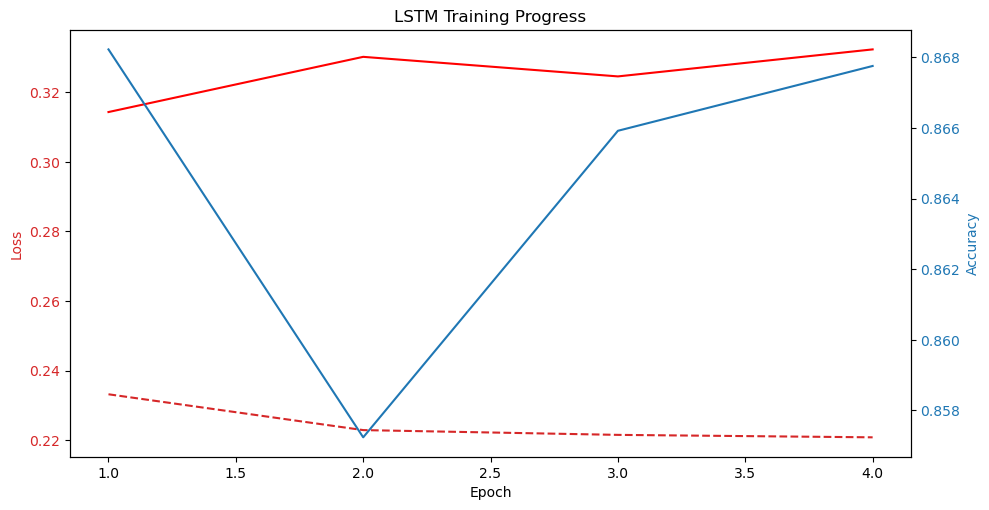

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history_df):
    fig, ax1 = plt.subplots(figsize=(10, 5))


    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_accuracy'], label='Val Accuracy', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    fig.tight_layout()
    plt.title('LSTM Training Progress')
    plt.show()

plot_training_history(history_df)

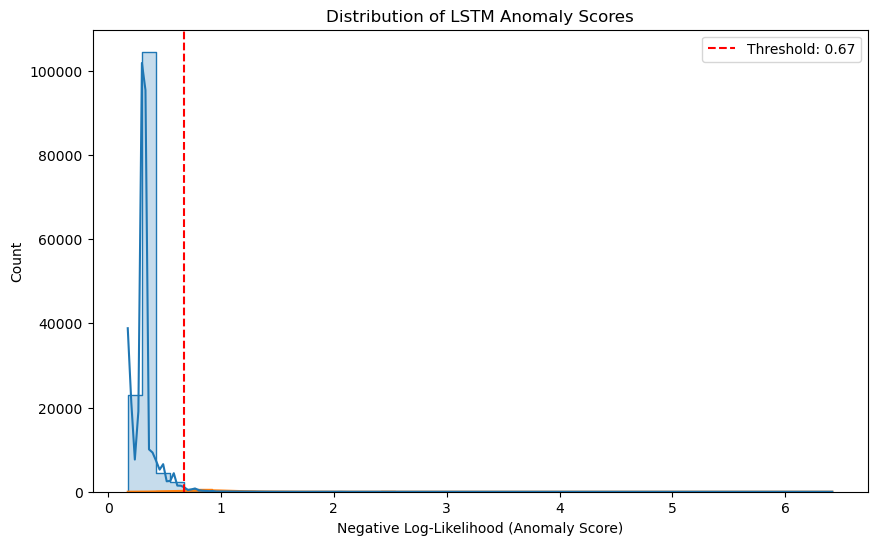

In [ ]:
import seaborn as sns

def plot_anomaly_distribution(df, threshold):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='lstm_score', hue='label', bins=50, kde=True, element="step")
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.2f}')
    plt.title('Distribution of LSTM Anomaly Scores')
    plt.xlabel('Negative Log-Likelihood (Anomaly Score)')
    plt.legend()
    plt.show()

plot_anomaly_distribution(test_df, best_lstm["threshold"])

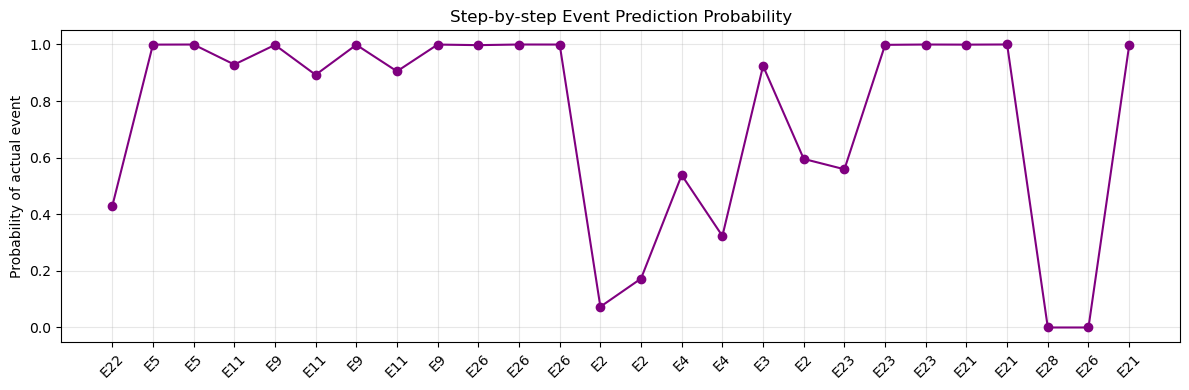

In [ ]:
def visualize_sequence_anomaly(seq, model, vocab, max_len, device):
    model.eval()
    seq_ids = [vocab.get(token, vocab["<UNK>"]) for token in seq]
    tokens = seq
    probs_list = []

    for i in range(1, len(seq_ids)):
        prefix = seq_ids[:i]
        target = seq_ids[i]
        if len(prefix) > max_len: prefix = prefix[-max_len:]

        input_ids = torch.tensor([prefix + [0]*(max_len-len(prefix))], dtype=torch.long).to(device)
        lengths = torch.tensor([len(prefix)], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(input_ids, lengths)
            prob = torch.softmax(logits, dim=1)[0, target].item()
            probs_list.append(prob)


    plt.figure(figsize=(12, 4))
    plt.plot(range(1, len(seq)), probs_list, marker='o', linestyle='-', color='purple')
    plt.xticks(range(1, len(seq)), tokens[1:], rotation=45)
    plt.ylabel('Probability of actual event')
    plt.title('Step-by-step Event Prediction Probability')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
sample_anomaly = test_df[test_df['label'] == 1]['sequence'].iloc[0]
visualize_sequence_anomaly(sample_anomaly, model, vocab, MAX_LEN, device)

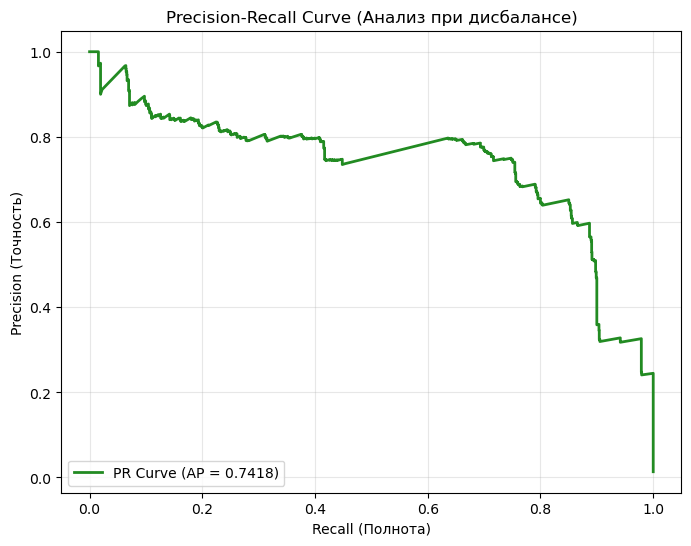

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(labels, scores):
    precision, recall, _ = precision_recall_curve(labels, scores)
    avg_precision = average_precision_score(labels, scores)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='forestgreen', lw=2,
             label=f'PR Curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall (Полнота)')
    plt.ylabel('Precision (Точность)')
    plt.title('Precision-Recall Curve (Анализ при дисбалансе)')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_pr_curve(test_df['label'], test_df['lstm_score'])

C:\Users\serge\AppData\Local\Temp\ipykernel_12056\1898095799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='lstm_score', data=df, palette='Set2')


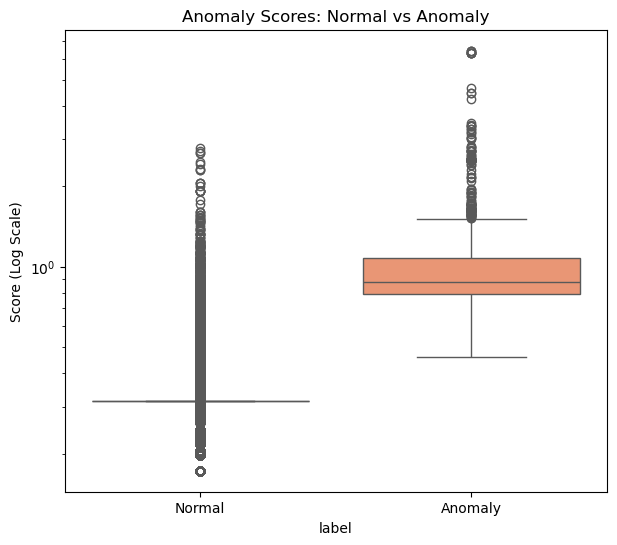

In [ ]:
def plot_score_boxplot(df):
    plt.figure(figsize=(7, 6))
    sns.boxplot(x='label', y='lstm_score', data=df, palette='Set2')
    plt.yscale('log')
    plt.title('Anomaly Scores: Normal vs Anomaly')
    plt.xticks([0, 1], ['Normal', 'Anomaly'])
    plt.ylabel('Score (Log Scale)')
    plt.show()

plot_score_boxplot(test_df)

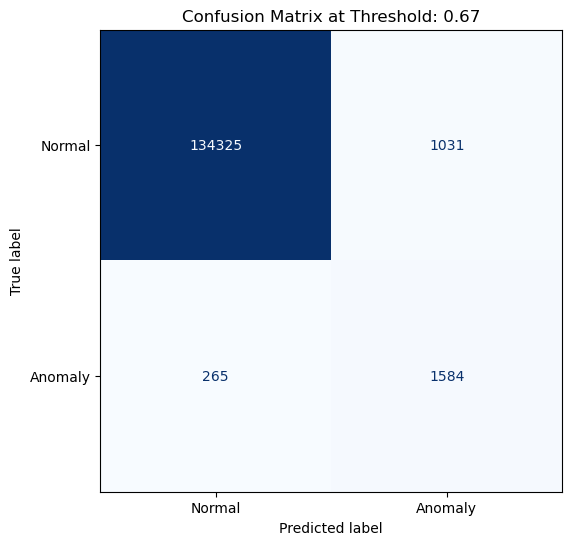

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(labels, scores, threshold):
    preds = (scores >= threshold).astype(int)
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f'Confusion Matrix at Threshold: {threshold:.2f}')
    plt.show()

plot_confusion_matrix(test_df['label'], test_df['lstm_score'], best_lstm["threshold"])

In [ ]:
@torch.no_grad()
def lstm_step_scores(seq, model, vocab, max_len, device):
    model.eval()

    seq_ids = [vocab.get(token, vocab["<UNK>"]) for token in seq]

    step_scores = []
    step_targets = []

    for i in range(1, len(seq_ids)):
        prefix = seq_ids[:i]
        target = seq_ids[i]

        if len(prefix) > max_len:
            prefix = prefix[-max_len:]

        length = len(prefix)
        prefix_padded = prefix + [0] * (max_len - length)

        input_ids = torch.tensor([prefix_padded], dtype=torch.long).to(device)
        lengths = torch.tensor([length], dtype=torch.long).to(device)

        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1)

        prob = probs[0, target].item()
        score = -np.log(prob + 1e-12)

        step_scores.append(score)
        step_targets.append(seq[i])

    return step_scores, step_targets

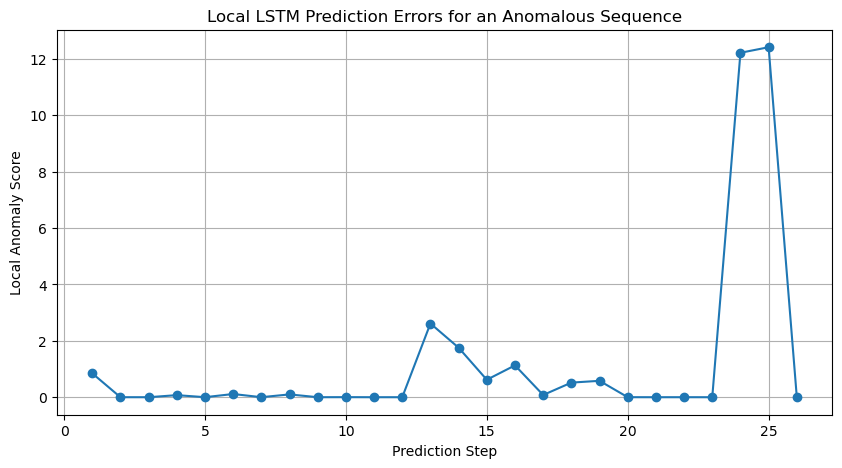

In [ ]:
example_anomaly = test_df[test_df["label"] == 1].iloc[0]

step_scores, step_targets = lstm_step_scores(
    seq=example_anomaly["sequence"],
    model=model,
    vocab=vocab,
    max_len=MAX_LEN,
    device=device
)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(step_scores) + 1), step_scores, marker="o")

plt.xlabel("Prediction Step")
plt.ylabel("Local Anomaly Score")
plt.title("Local LSTM Prediction Errors for an Anomalous Sequence")
plt.grid(True)
plt.show()

# Transformer

In [ ]:
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]


class TransformerNextEvent(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.3,
        max_len=512
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0  # True для PAD

        output = self.transformer(
            x,
            src_key_padding_mask=key_padding_mask
        )

        lengths = attention_mask.sum(dim=1)  # [batch]
        idx = (lengths - 1).unsqueeze(1).unsqueeze(2).expand(-1, 1, output.size(2))
        last_hidden = output.gather(1, idx).squeeze(1)

        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden)
        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transformer_model = TransformerNextEvent(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.3,
    max_len=MAX_LEN
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Device: cuda


C:\Users\serge\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import copy

def train_one_epoch_transformer(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Train", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
@torch.no_grad()
def evaluate_transformer_next_event(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc
    }

In [ ]:
num_epochs = 10
patience = 3

best_val_loss = float("inf")
best_state = None
best_epoch = -1
patience_counter = 0

history_transformer = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch_transformer(
        transformer_model, train_loader, optimizer, criterion, device
    )

    val_metrics = evaluate_transformer_next_event(
        transformer_model, normal_val_loader, criterion, device
    )

    history_transformer.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"]
    })

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_metrics['loss']:.4f}, val accuracy: {val_metrics['accuracy']:.4f}")

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = copy.deepcopy(transformer_model.state_dict())
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest epoch: {best_epoch}, best val loss: {best_val_loss:.4f}")

if best_state is not None:
    transformer_model.load_state_dict(best_state)

history_transformer_df = pd.DataFrame(history_transformer)
print(history_transformer_df)


Epoch 1/10
Train loss: 0.2520
Val loss: 0.3378, val accuracy: 0.8416



Epoch 2/10
Train loss: 0.2387
Val loss: 0.3010, val accuracy: 0.8718



Epoch 3/10
Train loss: 0.2362
Val loss: 0.3152, val accuracy: 0.8710



Epoch 4/10
Train loss: 0.2351
Val loss: 0.3105, val accuracy: 0.8749



Epoch 5/10
Train loss: 0.2345
Val loss: 0.3040, val accuracy: 0.8746

Early stopping at epoch 5

Best epoch: 2, best val loss: 0.3010
   epoch  train_loss  val_loss  val_accuracy
0      1    0.252049  0.337803      0.841605
1      2    0.238676  0.300972      0.871797
2      3    0.236235  0.315244      0.870953
3      4    0.235142  0.310461      0.874884
4      5    0.234455  0.303960      0.874643


In [ ]:
@torch.no_grad()
def transformer_anomaly_score(seq, model, vocab, max_len, device):
    model.eval()

    seq_ids = [vocab.get(token, vocab["<UNK>"]) for token in seq]
    scores = []

    for i in range(1, len(seq_ids)):
        prefix = seq_ids[:i]
        target = seq_ids[i]

        if len(prefix) > max_len:
            prefix = prefix[-max_len:]

        length = len(prefix)
        prefix_padded = prefix + [0] * (max_len - length)
        attention_mask = [1] * length + [0] * (max_len - length)

        input_ids = torch.tensor([prefix_padded], dtype=torch.long).to(device)
        attention_mask = torch.tensor([attention_mask], dtype=torch.long).to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)

        prob = probs[0, target].item()
        scores.append(-np.log(prob + 1e-12))

    if len(scores) == 0:
        return 0.0

    return float(np.mean(scores))

In [ ]:
val_df["transformer_score"] = val_df["sequence"].apply(
    lambda x: transformer_anomaly_score(x, transformer_model, vocab, MAX_LEN, device)
)

test_df["transformer_score"] = test_df["sequence"].apply(
    lambda x: transformer_anomaly_score(x, transformer_model, vocab, MAX_LEN, device)
)

best_transformer = find_best_threshold(val_df["transformer_score"], val_df["label"])
print("Best Transformer threshold:", best_transformer)

transformer_metrics = evaluate_anomaly_scores(
    test_labels=test_df["label"],
    test_scores=test_df["transformer_score"],
    threshold=best_transformer["threshold"]
)

print("\nTransformer model")
for k, v in transformer_metrics.items():
    print(f"{k}: {v:.4f}")

Best Transformer threshold: {'threshold': np.float64(0.8981444929842249), 'f1': 0.7181846059490954, 'precision': 0.7683727034120735, 'recall': 0.6741508347725964}

Transformer model
accuracy: 0.9935
precision: 0.7685
recall: 0.7415
f1: 0.7547
roc_auc: 0.9931
pr_auc: 0.7665


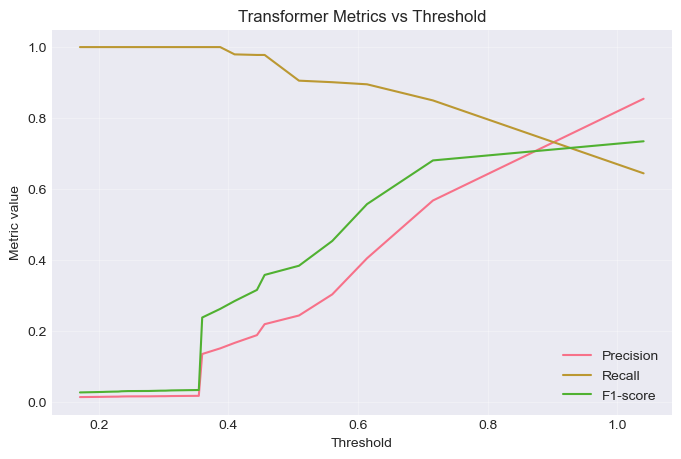

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def plot_metrics_vs_threshold(labels, scores):
    thresholds = np.quantile(scores, np.linspace(0.01, 0.99, 100))
    rows = []

    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        rows.append({
            "threshold": thr,
            "precision": precision_score(labels, preds, zero_division=0),
            "recall": recall_score(labels, preds, zero_division=0),
            "f1": f1_score(labels, preds, zero_division=0)
        })

    df_thr = pd.DataFrame(rows)

    plt.figure(figsize=(8, 5))
    plt.plot(df_thr["threshold"], df_thr["precision"], label="Precision")
    plt.plot(df_thr["threshold"], df_thr["recall"], label="Recall")
    plt.plot(df_thr["threshold"], df_thr["f1"], label="F1-score")
    plt.xlabel("Threshold")
    plt.ylabel("Metric value")
    plt.title("Transformer Metrics vs Threshold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_metrics_vs_threshold(test_df["label"].values, test_df["transformer_score"].values)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("seaborn-v0_8-darkgrid")

In [ ]:
def plot_training_history(history_df, model_name="Transformer"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="s", label="Validation Loss")

    best_idx = history_df["val_loss"].idxmin()
    best_epoch = history_df.loc[best_idx, "epoch"]
    best_loss = history_df.loc[best_idx, "val_loss"]

    axes[0].scatter(best_epoch, best_loss, s=100, color="red", zorder=5)
    axes[0].axvline(best_epoch, linestyle="--", color="red", alpha=0.6)

    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="s", label="Validation Accuracy")

    best_acc_idx = history_df["val_accuracy"].idxmax()
    best_acc_epoch = history_df.loc[best_acc_idx, "epoch"]
    best_acc = history_df.loc[best_acc_idx, "val_accuracy"]

    axes[1].scatter(best_acc_epoch, best_acc, s=100, color="red", zorder=5)

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} Model Training Progress", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

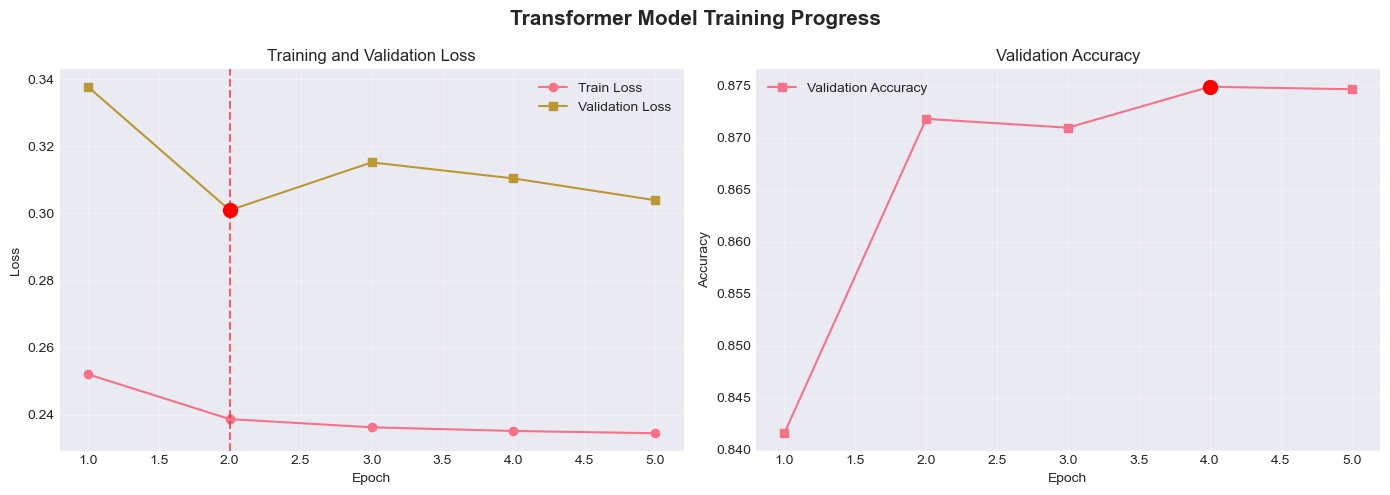

In [ ]:
plot_training_history(history_transformer_df, model_name="Transformer")

In [ ]:
def plot_anomaly_score_distribution(df, score_col, threshold, model_name="Transformer"):
    normal_scores = df[df["label"] == 0][score_col]
    anomaly_scores = df[df["label"] == 1][score_col]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(normal_scores, bins=50, alpha=0.7, label="Normal", density=True)
    axes[0].hist(anomaly_scores, bins=50, alpha=0.7, label="Anomaly", density=True)
    axes[0].axvline(threshold, linestyle="--", linewidth=2, color="black",
                    label=f"Threshold = {threshold:.3f}")

    axes[0].set_title("Distribution of Anomaly Scores")
    axes[0].set_xlabel("Anomaly Score")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    box_data = [normal_scores, anomaly_scores]
    axes[1].boxplot(box_data, labels=["Normal", "Anomaly"], patch_artist=True)
    axes[1].axhline(threshold, linestyle="--", linewidth=2, color="black",
                    label=f"Threshold = {threshold:.3f}")

    axes[1].set_title("Box Plot Comparison")
    axes[1].set_ylabel("Anomaly Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"{model_name}: Anomaly Score Analysis", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

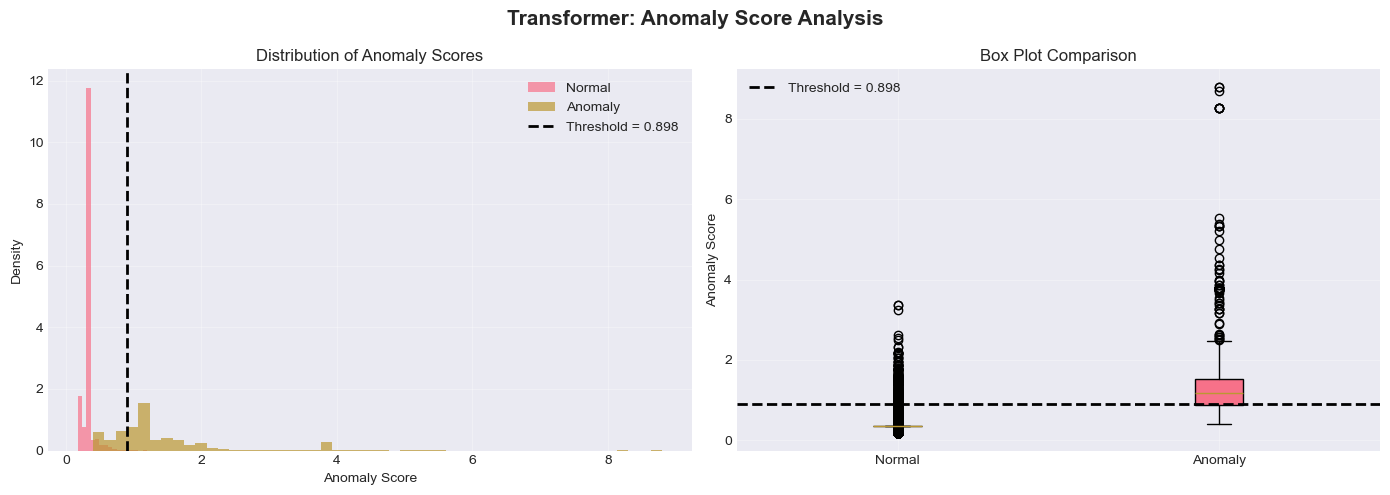

In [ ]:
plot_anomaly_score_distribution(
    test_df,
    score_col="transformer_score",
    threshold=best_transformer["threshold"],
    model_name="Transformer"
)

# Transformer Time

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn

from tqdm import tqdm
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader

In [ ]:
def compute_time_stats_streaming(df, col="time_seq"):
    total_sum = 0.0
    total_sq_sum = 0.0
    total_count = 0

    for seq in df[col]:
        if seq is None or len(seq) == 0:
            continue

        arr = np.asarray(seq, dtype=np.float32)

        if np.any(arr < 0):
            raise ValueError("В time_seq есть отрицательные значения, log1p применять нельзя")

        arr = np.log1p(arr)

        total_sum += arr.sum(dtype=np.float64)
        total_sq_sum += np.square(arr, dtype=np.float32).sum(dtype=np.float64)
        total_count += arr.size

    if total_count == 0:
        raise ValueError("Не удалось посчитать статистики времени: все последовательности пустые")

    mean = total_sum / total_count
    var = total_sq_sum / total_count - mean ** 2
    var = max(var, 1e-12)
    std = np.sqrt(var)

    return float(mean), float(std)


def normalize_time_seq(seq, mean, std):
    arr = np.asarray(seq, dtype=np.float32)

    if np.any(arr < 0):
        raise ValueError("В time_seq есть отрицательные значения, log1p применять нельзя")

    arr = np.log1p(arr)
    arr = (arr - mean) / (std + 1e-8)
    return arr.tolist()


time_mean, time_std = compute_time_stats_streaming(normal_train_df, col="time_seq")

for split_df in [train_df, val_df, test_df, normal_train_df, normal_val_df]:
    split_df["time_seq_norm"] = split_df["time_seq"].apply(
        lambda x: normalize_time_seq(x, time_mean, time_std)
    )

print("time_mean =", time_mean)
print("time_std =", time_std)

time_mean = 1.6589150871237608
time_std = 2.7259736939404013


In [ ]:
mins = [min(seq) for seq in normal_train_df["sequence_ids"] if len(seq) > 0]
maxs = [max(seq) for seq in normal_train_df["sequence_ids"] if len(seq) > 0]

print("min token:", min(mins))
print("max token:", max(maxs))
print("len(vocab):", len(vocab))

min token: 2
max token: 17
len(vocab): 18


In [ ]:
class NextEventTimeDataset(Dataset):
    def __init__(self, dataframe, max_len, max_prefixes_per_seq=10):
        self.samples = []
        self.max_len = max_len

        for _, row in dataframe.iterrows():
            seq = row["sequence_ids"]
            time_seq = row["time_seq_norm"]

            if seq is None or len(seq) < 2:
                continue

            prefix_positions = list(range(1, len(seq)))
            if len(prefix_positions) > max_prefixes_per_seq:
                prefix_positions = prefix_positions[-max_prefixes_per_seq:]

            for i in prefix_positions:
                prefix = seq[:i]
                target = seq[i]

                prefix_times = [0.0] + time_seq[:i-1]

                if len(prefix) > self.max_len:
                    prefix = prefix[-self.max_len:]
                    prefix_times = prefix_times[-self.max_len:]

                length = len(prefix)

                input_ids = prefix + [0] * (self.max_len - length)
                time_values = prefix_times + [0.0] * (self.max_len - length)
                attention_mask = [1] * length + [0] * (self.max_len - length)

                self.samples.append({
                    "input_ids": input_ids,
                    "time_values": time_values,
                    "attention_mask": attention_mask,
                    "target": target
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "time_values": torch.tensor(item["time_values"], dtype=torch.float32),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "target": torch.tensor(item["target"], dtype=torch.long)
        }

In [ ]:
max_len = 50
batch_size = 64

train_time_dataset = NextEventTimeDataset(
    normal_train_df,
    max_len=max_len,
    max_prefixes_per_seq=10
)

val_time_dataset = NextEventTimeDataset(
    normal_val_df,
    max_len=max_len,
    max_prefixes_per_seq=10
)

train_time_loader = DataLoader(
    train_time_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_time_loader = DataLoader(
    val_time_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("train samples:", len(train_time_dataset))
print("val samples:", len(val_time_dataset))

train samples: 3526080
val samples: 702370


In [ ]:
del train_time_dataset
del val_time_dataset
del train_time_loader
del val_time_loader
import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
vocab_size = len(vocab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerTimeNextEvent(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2,
        max_len=512
    ):
        super().__init__()

        self.event_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.time_projection = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, time_values, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()

        event_x = self.event_embedding(input_ids)
        time_x = self.time_projection(time_values.unsqueeze(-1))

        x = (event_x + time_x) * mask
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0

        seq_len = input_ids.size(1)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=input_ids.device, dtype=torch.bool),
            diagonal=1
        )

        output = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=key_padding_mask
        )

        lengths = attention_mask.sum(dim=1).clamp(min=1)
        idx = (lengths - 1).unsqueeze(1).unsqueeze(2).expand(-1, 1, output.size(2))
        last_hidden = output.gather(1, idx).squeeze(1)

        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden)

        return logits

In [ ]:
model = TransformerTimeNextEvent(
    vocab_size=vocab_size,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2,
    max_len=max_len
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
def train_one_epoch_transformer_time(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Train", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        time_values = batch["time_values"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(input_ids, time_values, attention_mask)
        loss = criterion(logits, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_transformer_time(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        time_values = batch["time_values"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        logits = model(input_ids, time_values, attention_mask)
        loss = criterion(logits, targets)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_targets, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc
    }

In [ ]:
sample = train_time_dataset[0]
for k, v in sample.items():
    print(k, v.shape, v.dtype)
    if v.ndim == 0:
        print(v.item())
    else:
        print(v[:10])

batch = next(iter(train_time_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)

input_ids = batch["input_ids"].to(device)
time_values = batch["time_values"].to(device)
attention_mask = batch["attention_mask"].to(device)
targets = batch["target"].to(device)

model.eval()
with torch.no_grad():
    logits = model(input_ids, time_values, attention_mask)

loss = criterion(logits, targets)

print("logits shape:", logits.shape)
print("loss:", loss.item())
print("logits has nan:", torch.isnan(logits).any().item())
print("loss is nan:", torch.isnan(loss).item())

input_ids torch.Size([50]) torch.int64
tensor([2, 3, 2, 2, 4, 5, 4, 5, 4, 5])
time_values torch.Size([50]) torch.float32
tensor([ 0.0000, -0.6086, -0.3543, -0.6086, -0.6086, -0.6086, -0.6086, -0.6086,
        -0.6086, -0.6086])
attention_mask torch.Size([50]) torch.int64
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
target torch.Size([]) torch.int64
6
input_ids torch.Size([64, 50]) torch.int64
time_values torch.Size([64, 50]) torch.float32
attention_mask torch.Size([64, 50]) torch.int64
target torch.Size([64]) torch.int64
logits shape: torch.Size([64, 18])
loss: 2.8039968013763428
logits has nan: False
loss is nan: False


In [ ]:
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())

patience = 2
patience_counter = 0
num_epochs = 4

history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch_transformer_time(
        model, train_time_loader, optimizer, criterion, device
    )

    val_metrics = evaluate_transformer_time(
        model, val_time_loader, criterion, device
    )

    val_loss = val_metrics["loss"]
    val_acc = val_metrics["accuracy"]

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_state)
model.to(device)

Epoch 1/4 | train_loss=0.1661 | val_loss=0.2033 | val_acc=0.9424


Epoch 2/4 | train_loss=0.1466 | val_loss=0.1729 | val_acc=0.9447


Epoch 3/4 | train_loss=0.1438 | val_loss=0.1700 | val_acc=0.9450


Epoch 4/4 | train_loss=0.1422 | val_loss=0.1792 | val_acc=0.9450


TransformerTimeNextEvent(
  (event_embedding): Embedding(18, 64, padding_idx=0)
  (time_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=18, bias=True)
)

In [ ]:
@torch.no_grad()
def sequence_anomaly_score_transformer_time(model, seq_ids, time_seq_norm, max_len, device):
    model.eval()

    if len(seq_ids) < 2:
        return None

    step_scores = []

    for i in range(1, len(seq_ids)):
        prefix = seq_ids[:i]
        target = seq_ids[i]

        prefix_times = [0.0] + time_seq_norm[:i-1]

        if len(prefix) > max_len:
            prefix = prefix[-max_len:]
            prefix_times = prefix_times[-max_len:]

        length = len(prefix)

        input_ids = prefix + [0] * (max_len - length)
        time_values = prefix_times + [0.0] * (max_len - length)
        attention_mask = [1] * length + [0] * (max_len - length)

        input_ids = torch.tensor([input_ids], dtype=torch.long, device=device)
        time_values = torch.tensor([time_values], dtype=torch.float32, device=device)
        attention_mask = torch.tensor([attention_mask], dtype=torch.long, device=device)

        logits = model(input_ids, time_values, attention_mask)
        probs = torch.softmax(logits, dim=-1)[0]

        true_prob = probs[target].item()
        true_prob = max(true_prob, 1e-12)

        step_scores.append(-np.log(true_prob))

    if len(step_scores) == 0:
        return None

    return float(np.mean(step_scores))

In [ ]:
val_scores = []
val_labels = []

for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Scoring val"):
    score = sequence_anomaly_score_transformer_time(
        model=model,
        seq_ids=row["sequence_ids"],
        time_seq_norm=row["time_seq_norm"],
        max_len=max_len,
        device=device
    )
    if score is not None:
        val_scores.append(score)
        val_labels.append(row["label"])

print("val scored:", len(val_scores))

Scoring val: 100%|███████████████████████████████████████████████████████████████| 71974/71974 [49:36<00:00, 24.18it/s]

val scored: 71974


In [ ]:
val_scores_np = np.array(val_scores)
val_labels_np = np.array(val_labels)

normal_mask = val_labels_np == 0
anomaly_mask = val_labels_np == 1

print("normal mean score:", val_scores_np[normal_mask].mean() if normal_mask.any() else None)
print("anomaly mean score:", val_scores_np[anomaly_mask].mean() if anomaly_mask.any() else None)

normal mean score: 0.646858063285729
anomaly mean score: 1.454504741906761


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_scores_np = np.array(val_scores)
val_labels_np = np.array(val_labels)

roc_auc = roc_auc_score(val_labels_np, val_scores_np)
pr_auc = average_precision_score(val_labels_np, val_scores_np)

print("Validation ROC-AUC:", roc_auc)
print("Validation PR-AUC:", pr_auc)

Validation ROC-AUC: 0.8147440261657404
Validation PR-AUC: 0.5040810607090364


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.unique(val_scores_np)
best_threshold = None
best_f1 = -1
best_precision = None
best_recall = None

for thr in thresholds:
    preds = (val_scores_np >= thr).astype(int)

    f1 = f1_score(val_labels_np, preds, zero_division=0)
    precision = precision_score(val_labels_np, preds, zero_division=0)
    recall = recall_score(val_labels_np, preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr
        best_precision = precision
        best_recall = recall

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)
print("Best validation precision:", best_precision)
print("Best validation recall:", best_recall)

Best threshold: 1.4173576394872218
Best validation F1: 0.5504850880344951
Best validation precision: 0.7323135755258127
Best validation recall: 0.4409902130109384


In [ ]:
test_scores = []
test_labels = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Scoring test"):
    score = sequence_anomaly_score_transformer_time(
        model=model,
        seq_ids=row["sequence_ids"],
        time_seq_norm=row["time_seq_norm"],
        max_len=max_len,
        device=device
    )
    if score is not None:
        test_scores.append(score)
        test_labels.append(row["label"])

print("test scored:", len(test_scores))

Scoring test: 100%|██████████████████████████████████████████████████████████| 137205/137205 [1:43:00<00:00, 22.20it/s]

test scored: 137205


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

test_scores_np = np.array(test_scores)
test_labels_np = np.array(test_labels)

test_preds = (test_scores_np >= best_threshold).astype(int)

test_accuracy = accuracy_score(test_labels_np, test_preds)
test_precision = precision_score(test_labels_np, test_preds, zero_division=0)
test_recall = recall_score(test_labels_np, test_preds, zero_division=0)
test_f1 = f1_score(test_labels_np, test_preds, zero_division=0)
test_roc_auc = roc_auc_score(test_labels_np, test_scores_np)
test_pr_auc = average_precision_score(test_labels_np, test_scores_np)
test_cm = confusion_matrix(test_labels_np, test_preds)

print("Test accuracy:", test_accuracy)
print("Test precision:", test_precision)
print("Test recall:", test_recall)
print("Test F1:", test_f1)
print("Test ROC-AUC:", test_roc_auc)
print("Test PR-AUC:", test_pr_auc)
print("Confusion matrix:")
print(test_cm)

Test accuracy: 0.9894828905652127
Test precision: 0.7063008130081301
Test recall: 0.3758788534342888
Test F1: 0.4906459583480409
Test ROC-AUC: 0.9515896513492269
Test PR-AUC: 0.5727824054946684
Confusion matrix:
[[135067    289]
 [  1154    695]]
